# 標準偏差について
**2026/04/27(月)**  
**落合**   

1. 標本標準偏差と母集団標準偏差
    - 母分散
        $$
            \sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (X_i - \mu)^2
        $$
    - 不偏分散
        $$
            s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar{X})^2
        $$
        $X_i$：データの各値,i番目の観測値  
        $n$：データの個数,サンプルサイズ  
        $\mu$：母平均,母集団の真の平均  
        $\bar{X}$：標本平均,データから計算した平均  
        <br>
        <br>
        標準偏差は分散の平方根をとったもの($\sigma,s$)

2. 母集団と標本とは
    - 母集団：調査の対象すべて，真の世界
    - 標本　：母集団から抽出した一部，観測したデータ  
        現実は収集したデータは標本であることがほとんど！

3. 母分散と標準偏差の式の違い<br>
    ① $n$で割るか，$n-1$で割るか<br>
    ② $\mu$で引くか，$\bar{X}$で引くか<br><br>
    
    1. 各データ$X_i$は母平均$\mu$より標本平均$\bar{X}$に近い性質があるため  
        $\mu$を使えないため$\bar{X}$で代用して分散を求める．  
        $\bar{X}$は$\mu$と一致せず、$X_i$は$\mu$よりも$\bar{x}$に近いところある.  
        したがって、  
        $$
        \sum_{i=1}^{n} (X_i - \mu)^2 \ge \sum_{i=1}^{n} (X_i - \bar{X})^2
        $$
        である．
        $n-1$で割ることによって、過小評価を補正する．
        
    2. $\bar{X}$は確率変数なので、そのバラつきも考慮すべきであるため  
        $\bar{X}$は取得するデータによって値が変わる．  
        そのブレの分だけ、バラつきを小さく見積もってしまう．

---

4. シミュレーションプログラム  
【概要】  
乱数(正規分布と一様分布)から10000のデータを作成し，それを母集団とする．  
そこから標本を抽出する作業を繰り返し，それらから$n$で割る分散、$n-1$で割る分散(不偏分散)に近いかシミュレーションする．

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'MS Gothic'

# -----------------------------
# 表示設定(小数点4桁)
# -----------------------------
np.set_printoptions(precision=4, suppress=True)  # numpy表示
pd.options.display.float_format = '{:.4f}'.format  # pandas表示

# -----------------------------
# ① 母集団を作成
# -----------------------------
np.random.seed(0)

N = 100000

population_normal = np.random.normal(loc=50, scale=10, size=N)
population_uniform = np.random.uniform(low=0, high=100, size=N)

# -----------------------------
# ② 母集団の統計量
# -----------------------------
def calc_population_stats(population, name):
    mean = np.mean(population)
    var = np.var(population)
    std = np.std(population)

    print(f"\n【{name}の母集団】")
    print(f"平均(母平均 μ)：{mean:.4f}")
    print(f"分散(分散 σ^2)：{var:.4f}")
    print(f"標準偏差(標準偏差 σ)：{std:.4f}")
    
    return mean, var, std

mean_n, var_n, std_n = calc_population_stats(population_normal, "正規分布")
mean_u, var_u, std_u = calc_population_stats(population_uniform, "一様分布")

# -----------------------------
# ③ シミュレーション
# -----------------------------
sample_size = 30
trials = 5000

results = []

def simulation(population, label):
    for _ in range(trials):
        sample = np.random.choice(population, size=sample_size)
        
        var_n = np.var(sample)
        var_n1 = np.var(sample, ddof=1)

        results.append({
            "type": label,
            "var_n": var_n,
            "var_n1": var_n1
        })

simulation(population_normal, "正規分布")
simulation(population_uniform, "一様分布")

df = pd.DataFrame(results)

# -----------------------------
# ④ 平均値で比較
# -----------------------------
summary = df.groupby("type")[["var_n", "var_n1"]].mean()

print("\n【標本分散の平均(試行平均)】")
print("※ 多数回試行した平均値で比較")
print(summary)

# 差も出す（直感補助）
summary["母分散との差(n)"] = summary["var_n"] - [var_n, var_u]
summary["母分散との差(n-1)"] = summary["var_n1"] - [var_n, var_u]

print("\n【母分散との差】")
print(summary)


【正規分布の母集団】
平均(母平均 μ)：50.0158
分散(分散 σ^2)：99.4686
標準偏差(標準偏差 σ)：9.9734

【一様分布の母集団】
平均(母平均 μ)：50.1303
分散(分散 σ^2)：834.1601
標準偏差(標準偏差 σ)：28.8818

【標本分散の平均(試行平均)】
※ 多数回試行した平均値で比較
        var_n   var_n1
type                  
一様分布 807.4582 835.3016
正規分布  95.6170  98.9141

【母分散との差】
        var_n   var_n1  母分散との差(n)  母分散との差(n-1)
type                                          
一様分布 807.4582 835.3016   707.9896     735.8330
正規分布  95.6170  98.9141  -738.5431    -735.2459


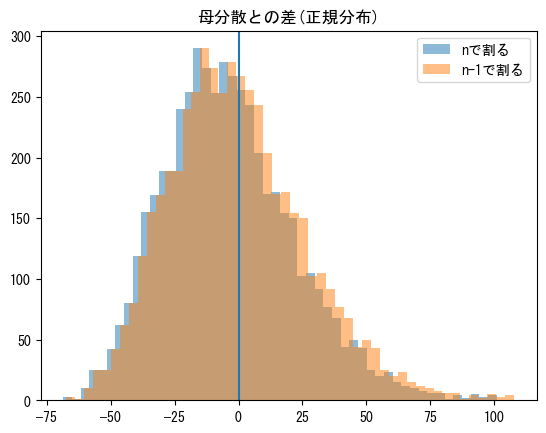

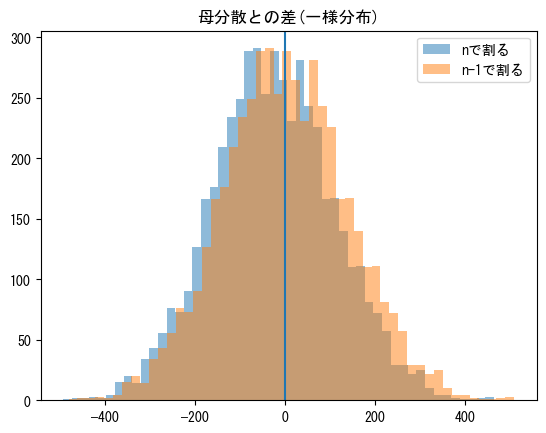

In [2]:
# -----------------------------
# ⑤ 可視化①：平均との差
# -----------------------------
plt.figure()

# 正規分布のみ表示
normal_df = df[df["type"] == "正規分布"]

# 母分散との差
diff_n = normal_df["var_n"] - var_n
diff_n1 = normal_df["var_n1"] - var_n

plt.hist(diff_n, bins=50, alpha=0.5, label="nで割る")
plt.hist(diff_n1, bins=50, alpha=0.5, label="n-1で割る")

plt.axvline(0)  # 母分散と一致ライン

plt.title("母分散との差(正規分布)")
plt.legend()
plt.show()

# -----------------------------
# 一様分布：母分散との差（ヒストグラム）
# -----------------------------
plt.figure()

uniform_df = df[df["type"] == "一様分布"]

# 母分散との差
diff_n_u = uniform_df["var_n"] - var_u
diff_n1_u = uniform_df["var_n1"] - var_u

plt.hist(diff_n_u, bins=50, alpha=0.5, label="nで割る")
plt.hist(diff_n1_u, bins=50, alpha=0.5, label="n-1で割る")

plt.axvline(0)  # 正解ライン

plt.title("母分散との差(一様分布)")
plt.legend()
plt.show()

In [3]:
# -----------------------------
# 標本サイズごとの比較
# -----------------------------
sample_sizes = [5, 10, 30, 100]

results_size = []

for size in sample_sizes:
    for _ in range(trials):
        sample = np.random.choice(population_normal, size=size)
        
        var_n = np.var(sample)
        var_n1 = np.var(sample, ddof=1)
        
        results_size.append({
            "sample_size": size,
            "var_n": var_n,
            "var_n1": var_n1
        })

df_size = pd.DataFrame(results_size)

# 平均をとる
summary_size = df_size.groupby("sample_size")[["var_n", "var_n1"]].mean()

print("\n【標本サイズごとの比較】")
print(summary_size)


【標本サイズごとの比較】
              var_n  var_n1
sample_size                
5           79.9702 99.9628
10          88.9432 98.8258
30          95.9909 99.3009
100         98.8016 99.7996


---

【概要】  
サンプルサイズを１~100へ増やしていき，$n$で割ったときと，$n-1$で割ったとき，どちらが母分散に近いかシミュレーションする．  
各サンプルサイズにおいて1000回実行し，分散はその平均値を採用する．  
その分散の値と母分散の差をグラフに描画する．

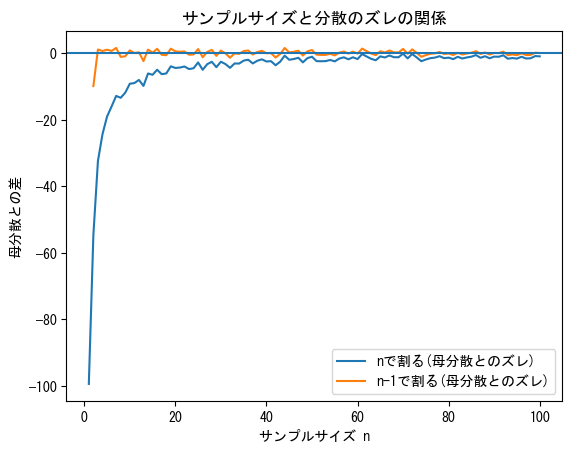

In [4]:
# -----------------------------
# サンプルサイズ 1〜100 の推移
# -----------------------------
sample_sizes = range(1, 101)
trials = 1000

results_curve = []

for size in sample_sizes:
    var_n_list = []
    var_n1_list = []
    
    for _ in range(trials):
        sample = np.random.choice(population_normal, size=size)
        
        var_n_list.append(np.var(sample))
        
        # size=1のときはn-1が0になるのでスキップ
        if size > 1:
            var_n1_list.append(np.var(sample, ddof=1))
    
    results_curve.append({
        "size": size,
        "var_n": np.mean(var_n_list),
        "var_n1": np.mean(var_n1_list) if size > 1 else np.nan
    })

df_curve = pd.DataFrame(results_curve)

# -----------------------------
# 母分散との差に変換
# -----------------------------
# 母分散
true_var = np.var(population_normal)

# 各分散との差
df_curve["diff_n"] = df_curve["var_n"] - true_var
df_curve["diff_n1"] = df_curve["var_n1"] - true_var

# -----------------------------
# グラフ描画
# -----------------------------
plt.figure()

plt.plot(df_curve["size"], df_curve["diff_n"], label="nで割る(母分散とのズレ)")
plt.plot(df_curve["size"], df_curve["diff_n1"], label="n-1で割る(母分散とのズレ)")

plt.axhline(0)

plt.xlabel("サンプルサイズ n")
plt.ylabel("母分散との差")
plt.title("サンプルサイズと分散のズレの関係")
plt.legend()
plt.show()

---

5. 数式での証明  
$$
\text{目的：} \quad 
\mathbb{E}\left[
\frac{1}{n-1}
\sum_{i=1}^{n}(X_i - \bar{X})^2
\right]
= \sigma^2
$$

$$
\text{① 分解}
$$

$$
(X_i - \bar{X}) = (X_i - \mu) - (\bar{X} - \mu)
$$

$$
\sum_{i=1}^{n}(X_i - \bar{X})^2
=
\sum_{i=1}^{n}(X_i - \mu)^2
- n(\bar{X} - \mu)^2
$$

$$
\text{② 期待値をとる}
$$

$$
\mathbb{E}\left[\sum_{i=1}^{n}(X_i - \bar{X})^2\right]
=
\mathbb{E}\left[\sum_{i=1}^{n}(X_i - \mu)^2\right]
-
\mathbb{E}\left[n(\bar{X} - \mu)^2\right]
$$

$$
\text{③ 各項を計算}
$$

$$
\mathbb{E}\left[\sum_{i=1}^{n}(X_i - \mu)^2\right] = n\sigma^2
$$

$$
\mathbb{E}\left[(\bar{X} - \mu)^2\right] = \frac{\sigma^2}{n}
$$

$$
\Rightarrow \quad
\mathbb{E}\left[n(\bar{X} - \mu)^2\right] = \sigma^2
$$

$$
\text{④ まとめ}
$$

$$
\mathbb{E}\left[\sum_{i=1}^{n}(X_i - \bar{X})^2\right]
=
(n-1)\sigma^2
$$

$$
\text{⑤ 両辺を } (n-1) \text{ で割る}
$$

$$
\mathbb{E}\left[
\frac{1}{n-1}
\sum_{i=1}^{n}(X_i - \bar{X})^2
\right]
=
\sigma^2
$$